# Funnel Analysis

**Context from user behavior analysis:** 32% of users are buyers, and cart adds / wishlist saves are nearly identical between buyers and non-buyers. This notebook quantifies conversion rates at each stage and tests whether those intent signals actually predict purchase.

In [39]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [40]:
df = run_sql("../sql/user_behavior_mart.sql")

total      = len(df)
viewers    = (df['views_count']     > 0).sum()
carted     = (df['cart_adds']       > 0).sum()
wishlisted = (df['wishlist_adds']   > 0).sum()
buyers     = (df['purchase_events'] > 0).sum()

print(f"Total:      {total:,}")
print(f"Viewers:    {viewers:,}  ({viewers/total*100:.1f}%)")
print(f"Carted:     {carted:,}  ({carted/total*100:.1f}%)")
print(f"Wishlisted: {wishlisted:,}  ({wishlisted/total*100:.1f}%)")
print(f"Buyers:     {buyers:,}  ({buyers/total*100:.1f}%)")

Total:      10,000
Viewers:    9,961  (99.6%)
Carted:     6,994  (69.9%)
Wishlisted: 5,504  (55.0%)
Buyers:     3,281  (32.8%)


## 1. Funnel: Users at Each Stage

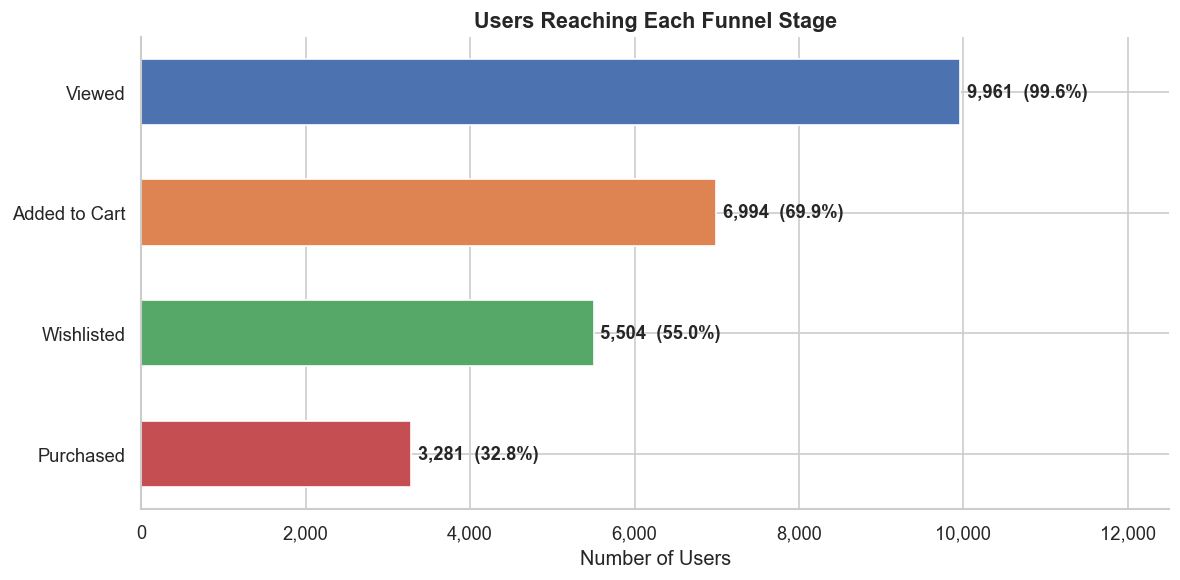

In [41]:
stages = pd.DataFrame({
    'Stage': ['Viewed', 'Added to Cart', 'Wishlisted', 'Purchased'],
    'Users': [viewers, carted, wishlisted, buyers]
})
stages['Pct'] = (stages['Users'] / total * 100).round(1)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stages['Stage'][::-1], stages['Users'][::-1],
               color=colors[::-1], edgecolor='white', height=0.55)

for bar, (_, row) in zip(bars, stages[::-1].iterrows()):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{row['Users']:,}  ({row['Pct']}%)",
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, total * 1.25)
ax.set_xlabel("Number of Users")
ax.set_title("Users Reaching Each Funnel Stage", fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.show()

99% of users viewed, 69% carted, 55% wishlisted intent signal reach is high. Only 32% purchased. The drop is not at awareness but at the final conversion step.

## 2. Stage-to-Stage Conversion Rates

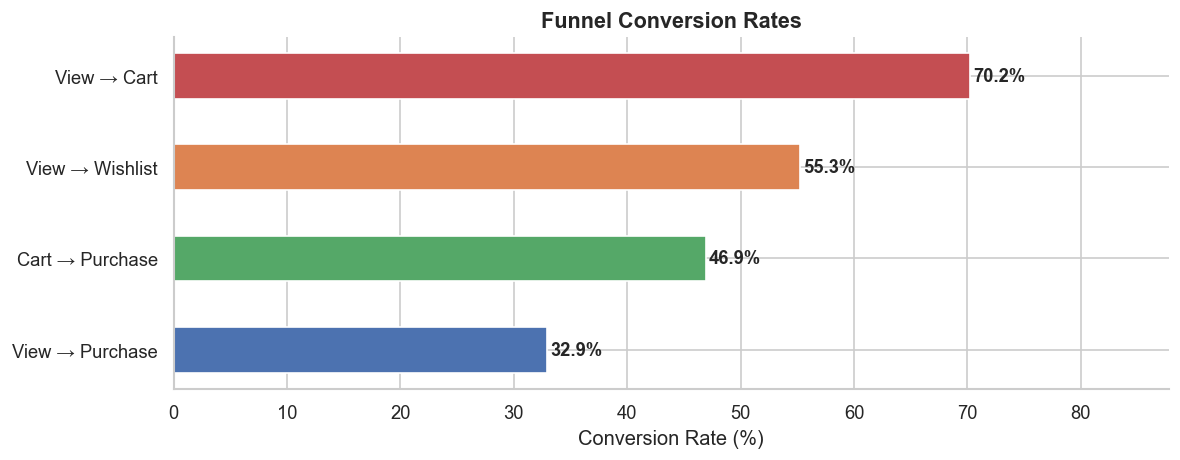

In [42]:
view_to_cart      = carted     / viewers * 100
view_to_wishlist  = wishlisted / viewers * 100
cart_to_purchase  = buyers     / carted  * 100
view_to_purchase  = buyers     / viewers * 100

rates = pd.DataFrame({
    'Transition':        ['View → Cart', 'View → Wishlist', 'Cart → Purchase', 'View → Purchase'],
    'Conversion Rate %': [view_to_cart, view_to_wishlist, cart_to_purchase, view_to_purchase]
})

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(rates['Transition'][::-1], rates['Conversion Rate %'][::-1],
               color=['#C44E52', '#DD8452', '#55A868', '#4C72B0'][::-1],
               edgecolor='white', height=0.5)

for bar, val in zip(bars, rates['Conversion Rate %'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, rates['Conversion Rate %'].max() * 1.25)
ax.set_xlabel("Conversion Rate (%)")
ax.set_title("Funnel Conversion Rates", fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

View-to-cart (~70%) and view-to-wishlist (~56%) are high users actively engage with intent features. Cart-to-purchase (~47%) looks reasonable in isolation, but Section 4 will show that carting predicts purchase no better than doing nothing at all.

## 3. Cart Abandonment

Added to cart:           6,994
  Converted to purchase: 2,313  (33.1%)
  Abandoned:             4,681  (66.9%)


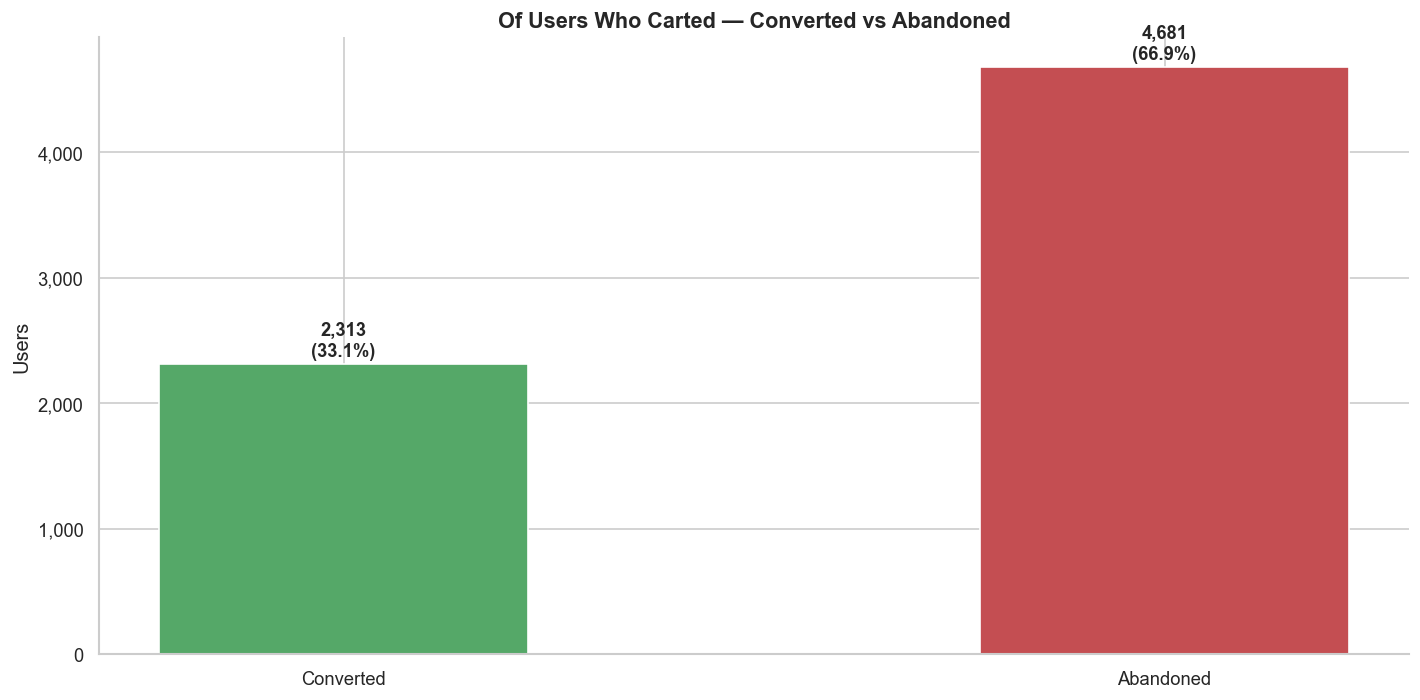

In [43]:
carted_bought    = ((df['cart_adds'] > 0) & (df['purchase_events'] > 0)).sum()
carted_abandoned = carted - carted_bought
abandonment_rate = carted_abandoned / carted * 100

print(f"Added to cart:           {carted:,}")
print(f"  Converted to purchase: {carted_bought:,}  ({carted_bought/carted*100:.1f}%)")
print(f"  Abandoned:             {carted_abandoned:,}  ({abandonment_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(['Converted', 'Abandoned'],
              [carted_bought, carted_abandoned],
              color=['#55A868', '#C44E52'], width=0.45, edgecolor='white')

for bar, val, pct in zip(bars,
                          [carted_bought, carted_abandoned],
                          [carted_bought/carted*100, abandonment_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Of Users Who Carted — Converted vs Abandoned", fontsize=13, fontweight='bold')
ax.set_ylabel("Users")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.show()

~67% of users who added to cart did not purchase. This is the main conversion leak in the funnel.

## 4. Does Cart or Wishlist Predict Purchase?

Baseline (all users):      32.8%
Carted users:              33.1%
Wishlisted users:          33.1%
Neither carted/wishlisted: 31.5%


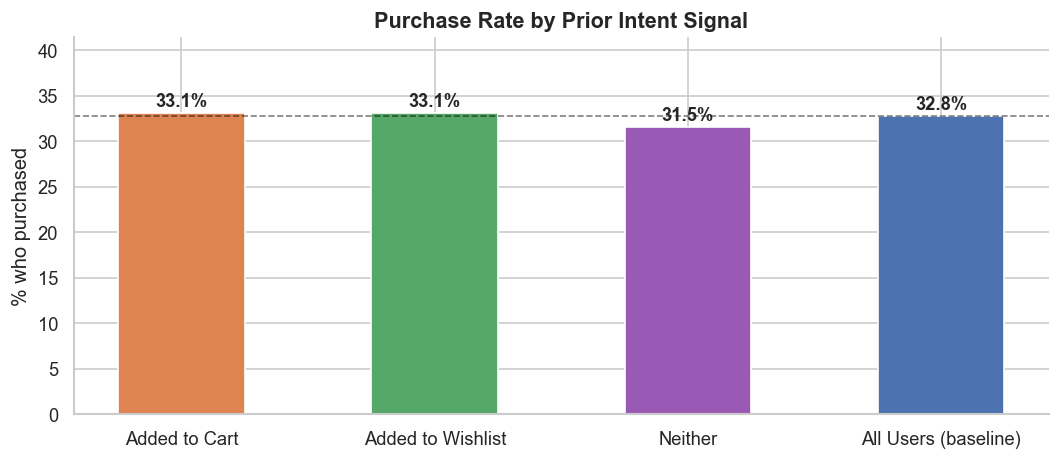

In [44]:
cart_purchase_rate     = ((df['cart_adds']     > 0) & (df['purchase_events'] > 0)).sum() / carted     * 100
wishlist_purchase_rate = ((df['wishlist_adds'] > 0) & (df['purchase_events'] > 0)).sum() / wishlisted * 100
neither                = (df['cart_adds'] == 0) & (df['wishlist_adds'] == 0)
neither_purchase_rate  = (neither & (df['purchase_events'] > 0)).sum() / neither.sum() * 100
baseline               = buyers / total * 100

print(f"Baseline (all users):      {baseline:.1f}%")
print(f"Carted users:              {cart_purchase_rate:.1f}%")
print(f"Wishlisted users:          {wishlist_purchase_rate:.1f}%")
print(f"Neither carted/wishlisted: {neither_purchase_rate:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
labels = ['Added to Cart', 'Added to Wishlist', 'Neither', 'All Users (baseline)']
values = [cart_purchase_rate, wishlist_purchase_rate, neither_purchase_rate, baseline]
colors = ['#DD8452', '#55A868', '#9B59B6', '#4C72B0']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(baseline, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title("Purchase Rate by Prior Intent Signal", fontsize=13, fontweight='bold')
ax.set_ylabel("% who purchased")
ax.set_ylim(0, max(values) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

Purchase rate is 33.1% for carted users, 33.1% for wishlisted users, and 31.5% for users who did neither all within ~1.5pp of the 32.8% baseline. Cart adds and wishlist saves carry virtually no predictive signal for purchase.

---

## Key Findings

- 99% of users viewed, 69% carted, 55% wishlisted intent signal reach is high across the board
- Only 32% purchased the drop is not at awareness but at conversion
- 67% of users who added to cart still did not buy cart abandonment is the primary leakage point
- Cart adds and wishlist saves have no meaningful predictive power: purchase rate is 33.1% for carted users vs 32.8% baseline
- High intent-signal reach combined with near-zero predictive lift suggests these actions are exploratory, not purchase-intent signals in this dataset